In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
 

 
 


In [2]:
# Set the seed for reproducibility
np.random.seed(42)

In [3]:
# Creamos nuestros datos artificiales (dos círculos concéntricos)
X, Y = make_circles(n_samples=1000, factor=0.5, noise=0.06)

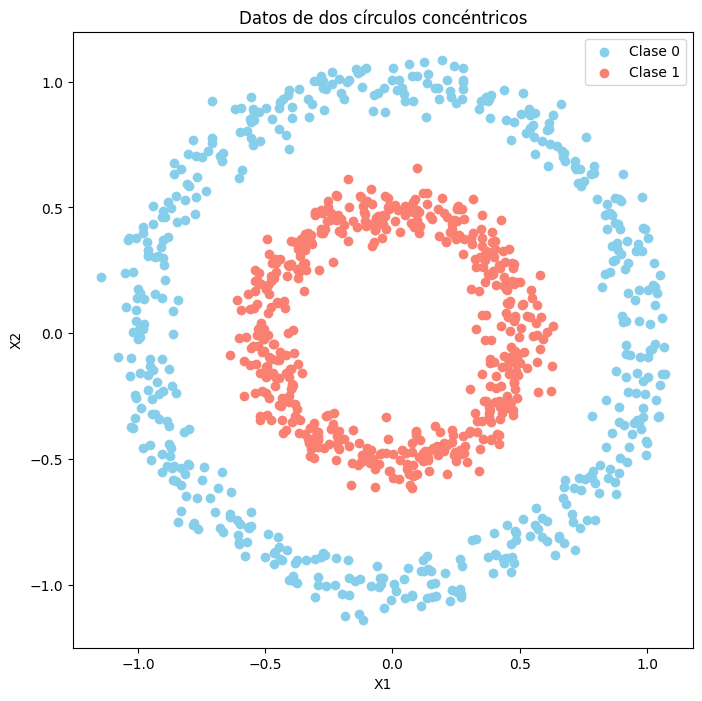

In [4]:
# Visualización de los datos generados
plt.figure(figsize=(8, 8))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1")
plt.title("Datos de dos círculos concéntricos")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

# dividir en 85 % entrenamiento / 15 % test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.15, random_state=42, stratify=Y
)

print(f"tamaño train: {X_train.shape[0]}, test: {X_test.shape[0]}")

tamaño train: 850, test: 150


In [6]:
#muestrame una parte de x_train y y_train
print("Primeros 5 ejemplos de X_train:")
print(X_train[:5])
print("\nPrimeros 5 ejemplos de Y_train:")
print(Y_train[:5])


Primeros 5 ejemplos de X_train:
[[-0.22306363  0.54874657]
 [ 0.44798276  0.84925952]
 [-0.6371443  -0.72830631]
 [-0.12575101 -0.9770037 ]
 [ 0.99805401 -0.42572967]]

Primeros 5 ejemplos de Y_train:
[1 0 0 0 0]


In [7]:
#Como el modelo es de clasificacion binomial quiero que uses sigmoid como funcion de activacion, y binary_crossentropy como funcion de perdida. Entrena el modelo durante 100 epocas con un batch size de 32. Ademas quiero que uses 3 capas ocultas, la primera con 16, la segunda con 8 y  la tercera con 4 neuronas. Usa el optimizador Adam con un learning rate 0.3
from tensorflow import keras
from tensorflow.keras import layers
# Crear el modelo secuencial
model = keras.Sequential(
    [
        layers.Input(shape=(2,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [8]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compilar el modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [10]:
#Crear una variable de earling stopping para evitar el sobreentrenamiento
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True,
    min_delta=0.001
)   

In [11]:
# Entrenar el modelo
history = model.fit(X_train, Y_train, epochs=1000, batch_size=32, validation_split=0.15, callbacks=[early_stopping])


Epoch 1/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4413 - loss: 0.6978 - val_accuracy: 0.4922 - val_loss: 0.6767
Epoch 2/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5741 - loss: 0.6558 - val_accuracy: 0.6953 - val_loss: 0.6015
Epoch 3/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7496 - loss: 0.5381 - val_accuracy: 0.9453 - val_loss: 0.3634
Epoch 4/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9727 - loss: 0.3218 - val_accuracy: 0.9922 - val_loss: 0.2431
Epoch 5/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9917 - loss: 0.2269 - val_accuracy: 1.0000 - val_loss: 0.1325
Epoch 6/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0784 - val_accuracy: 1.0000 - val_loss: 0.0129
Epoch 7/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 8/1000
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9981 - loss: 0.0059 - val_accuracy: 

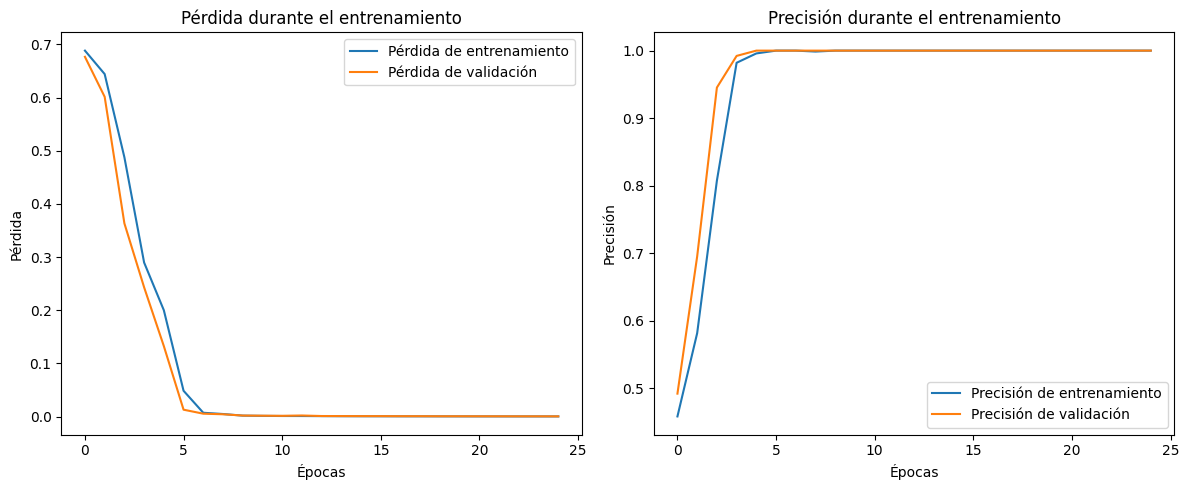

In [12]:
#Haz la grafica de la perdida y la precision durante el entrenamiento
plt.figure(figsize=(12, 5))
# Grafica de la pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Pérdida de entrenamiento")
plt.plot(history.history["val_loss"], label="Pérdida de validación")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
# Grafica de la precisión
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Precisión de entrenamiento")
plt.plot(history.history["val_accuracy"], label="Precisión de validación")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
#Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(X_test, Y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 3.4372e-04  
Test Loss: 0.0004, Test Accuracy: 1.0000


In [14]:
#Conectar con el drive y guardar el modelo entrenado
from google.colab import drive
drive.mount("/content/drive")
model.save("/content/drive/MyDrive/modelo_circulos.keras")


MessageError: [dfs_ephemeral] Credentials propagation unsuccessful